# 📰 Ctrl+Is+Hers Final — İkili Təsnifat Layihəsi

**Məqsəd:** Məqalə xüsusiyyətlərinə (mətn uzunluğu, açar sözlər, mövzu paylanması, sentiment və s.) əsasən `target` (0/1) dəyişənini proqnozlaşdırmaq.

**Qiymətləndirmə metrikası:** ROC-AUC (əlavə olaraq Accuracy, Precision, Recall, F1).

**Planlaşdırılan modellər:** Logistic Regression (baseline) → Random Forest → LightGBM.

---
### 1. Kitabxanaların import edilməsi

In [268]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split



from sklearn.metrics import (
    roc_auc_score)


from sklearn.ensemble import RandomForestClassifier

### 2. Datanın yüklənməsi
Kaggle müsabiqəsinin faylları `kagglehub` ilə endirilir.

**Nəticə:** Qovluqda 4 fayl var — `train.csv`, `test.csv`, `sample_submission.csv`, `metaData.csv`.

In [269]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('ctrl-is-hers-final')

print("Path to competition files:", path)

print(os.listdir(path))

Path to competition files: /kaggle/input/competitions/ctrl-is-hers-final
['sample_submission.csv', 'train.csv', 'metaData.csv', 'test.csv']


---
## 3. Datanın ilkin araşdırılması (EDA)
### 3.1 Struktur və tiplər
**Nəticə:** Train datası **31 715 sətir** və **49 sütundan** ibarətdir. Sütunların çoxu `float64`-dür; yalnız `publish_date`, `weekday`, `channel` `object` tipindədir. Hər sütunda 31 715 dolu dəyər var.

In [270]:
df = pd.read_csv(os.path.join(path, 'train.csv'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31715 entries, 0 to 31714
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            31715 non-null  int64  
 1   publish_date                  31715 non-null  object 
 2   weekday                       31715 non-null  object 
 3   channel                       31715 non-null  object 
 4   n_tokens_title                31715 non-null  float64
 5   n_tokens_content              31715 non-null  float64
 6   n_unique_tokens               31715 non-null  float64
 7   n_non_stop_words              31715 non-null  float64
 8   n_non_stop_unique_tokens      31715 non-null  float64
 9   num_hrefs                     31715 non-null  float64
 10  num_self_hrefs                31715 non-null  float64
 11  num_imgs                      31715 non-null  float64
 12  num_videos                    31715 non-null  float64
 13  a

### 3.2 İlk 5 sətir
Data məqalə səviyyəlidir: nəşr tarixi, həftənin günü, kanal (məs. *Entertainment*, *Business*, *Tech*), mətn statistikaları, açar söz göstəriciləri, LDA mövzu skorları və sentiment göstəriciləri.

In [271]:
df.head()

,id,publish_date,weekday,channel,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,target
0,0,2013-01-07,Monday,Entertainment,12.0,219.0,0.663594,1.0,0.815385,4.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,1,2013-01-07,Monday,Business,9.0,255.0,0.604743,1.0,0.791946,3.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,2,2013-01-07,Monday,Business,9.0,211.0,0.575130,1.0,0.663866,3.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,3,2013-01-07,Monday,Entertainment,9.0,531.0,0.503788,1.0,0.665635,9.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,4,2013-01-07,Monday,Tech,13.0,1072.0,0.415646,1.0,0.540890,19.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0


### 3.3 Çatışmayan dəyərlər
**Nəticə:** Bütün 49 sütunda çatışmayan dəyər **yoxdur (0)** — imputasiya lazım deyil.

In [272]:
df.isnull().sum().sort_values(ascending=False)

id                              0
publish_date                    0
weekday                         0
channel                         0
n_tokens_title                  0
n_tokens_content                0
n_unique_tokens                 0
n_non_stop_words                0
n_non_stop_unique_tokens        0
num_hrefs                       0
num_self_hrefs                  0
num_imgs                        0
num_videos                      0
average_token_length            0
num_keywords                    0
kw_min_min                      0
kw_max_min                      0
kw_avg_min                      0
kw_min_max                      0
kw_max_max                      0
kw_avg_max                      0
kw_min_avg                      0
kw_max_avg                      0
kw_avg_avg                      0
self_reference_min_shares       0
self_reference_max_shares       0
self_reference_avg_shares       0
LDA_00                          0
LDA_01                          0
LDA_02        

### 3.4 Dublikatlar
**Nəticə:** Dublikat sətir sayı **0**.

In [273]:
df.duplicated().sum() 

np.int64(0)

### 3.5 Ölçü və sütun adları
**Nəticə:** `shape = (31715, 49)`. Sütunlar 4 qrupa bölünür: *sayma* göstəriciləri (`n_tokens_*`, `num_*`), *açar söz* (`kw_*`), *mövzu* (`LDA_00–04`), *sentiment* (`*_polarity`, `*_subjectivity`).

In [274]:
print(df.shape)
print(df.columns)

(31715, 49)
Index(['id', 'publish_date', 'weekday', 'channel', 'n_tokens_title',
       'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words',
       'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs',
       'num_videos', 'average_token_length', 'num_keywords', 'kw_min_min',
       'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max',
       'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares',
       'self_reference_max_shares', 'self_reference_avg_shares', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
       'global_rate_negative_words', 'rate_positive_words',
       'rate_negative_words', 'avg_positive_polarity', 'min_positive_polarity',
       'max_positive_polarity', 'avg_negative_polarity',
       'min_negative_polarity', 'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity

### 3.6 Hədəf dəyişənin paylanması
| target | Say | Faiz |
|---|---|---|
| 1 | 17 357 | ≈54.7% |
| 0 | 14 358 | ≈45.3% |

**Nəticə:** Siniflər nisbətən balanslıdır (kiçik disbalans var), ona görə xüsusi balanslaşdırma (SMOTE, class weights) məcburi deyil.

In [275]:
df['target'].value_counts()

target
1    17357
0    14358
Name: count, dtype: int64

In [276]:
print(df.columns.tolist())

['id', 'publish_date', 'weekday', 'channel', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_shares', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity', 'min_positive_polarity', 'max_positive_polarity', 'avg_negative_polarity', 'min_negative_polarity', 'max_negative_polarity', 'title_subjectivity', 'title_sentiment_polarity', 'abs_title_subjectivity', 'abs_title_sentiment_polarity', 'target']


### 3.7 Hədəfin vizuallaşdırılması
Aşağıdakı qrafik yuxarıdakı rəqəmləri təsdiqləyir: `1` sinfi bir qədər üstündür.

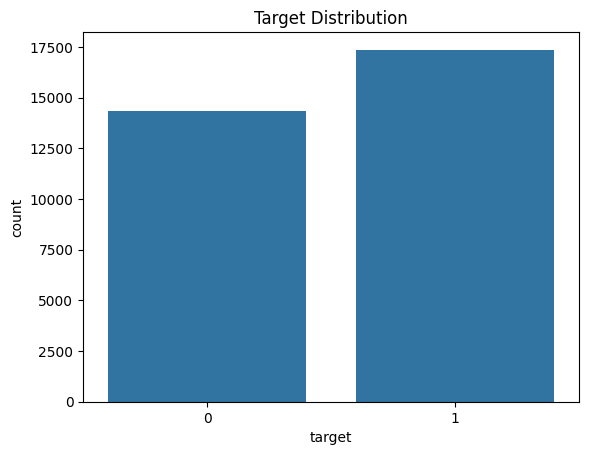

In [277]:
sns.countplot(data=df, x='target')
plt.title('Target Distribution')
plt.show()

### 3.8 `id` unikallığı
**Nəticə:** 31 715 unikal `id` — hər sətir ayrı məqalədir.

In [278]:
df['id'].nunique()

31715

### 3.9 Tarix sütunu
`publish_date` `datetime` tipinə çevrilir.

In [279]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['publish_date']

0       2013-01-07
1       2013-01-07
2       2013-01-07
3       2013-01-07
4       2013-01-07
           ...    
31710   2014-08-28
31711   2014-08-28
31712   2014-08-28
31713   2014-08-28
31714   2014-08-28
Name: publish_date, Length: 31715, dtype: datetime64[ns]

**Ən erkən tarix:** 2013-01-07

In [280]:
df['publish_date'].min()

Timestamp('2013-01-07 00:00:00')

**Ən gec tarix:** 2014-08-28

**Nəticə:** Data təxminən **20 ayı** əhatə edir. Bu, zaman əsaslı (time-based) validasiya üçün imkan yaradır.

In [281]:
df['publish_date'].max()

Timestamp('2014-08-28 00:00:00')

---
## 4. Feature hazırlığı
`target`, `id`, `publish_date` çıxarılır (identifikator və hədəf modelə verilməməlidir).

> ⚠️ **Diqqət:** Burada `X_valid`/`y_valid` eyni `df`-dən götürülür, yəni **validasiya datası = train datası**. Aşağıdakı bütün metriklər train üzərində hesablanıb və real nəticədən **optimistikdir**. Düzgün yol: `train_test_split` və ya tarixə görə bölgü.

In [282]:
X_train = df.drop(columns=['target', 'id', 'publish_date'])
y_train = df['target']

X_valid = df.drop(columns=['target', 'id', 'publish_date'])
y_valid = df['target']

### 4.1 Kateqorik və ədədi sütunlar
**Nəticə:** 2 kateqorik (`weekday`, `channel`) və 44 ədədi sütun.

In [283]:
categorical_cols = ['weekday', 'channel']

numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()
print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['weekday', 'channel']
Numeric: ['n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_shares', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity', 'min_positive_polarity', 'max_positive_polarity', 'avg_negative_polarity', 'min_negative_polarity', 'max_negative_polarity', 'title_subjectivity', 'title_sentiment_polarity', 'abs_title_subjectivity', 'abs_title_sentiment_polarity']


### 4.2 Preprocessing
- Ədədi sütunlar → `StandardScaler`
- Kateqorik sütunlar → `OneHotEncoder(handle_unknown='ignore')`

OHE-dən sonra feature sayı **58** olur (LightGBM logundan: *number of used features: 58*).

In [284]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

---
## 5. Modellər
### 5.1 Baseline — Logistic Regression

In [285]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

Pipeline (preprocessor + LogisticRegression) öyrədilir.

In [286]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['n_tokens_title',
                                                   'n_tokens_content',
                                                   'n_unique_tokens',
                                                   'n_non_stop_words',
                                                   'n_non_stop_unique_tokens',
                                                   'num_hrefs',
                                                   'num_self_hrefs', 'num_imgs',
                                                   'num_videos',
                                                   'average_token_length',
                                                   'num_keywords', 'kw_min_min',
                                                   'kw_max_min', 'kw_avg_min',
                                                   'kw_min_max', 'kw_max_max',
                                                   'kw_a...ax', 'kw_min_avg',
                                                   'kw_max_avg', 'kw_avg_avg',
                                                   'self_reference_min_shares',
                                                   'self_reference_max_shares',
                                                   'self_reference_avg_shares',
                                                   'LDA_00', 'LDA_01', 'LDA_02',
                                                   'LDA_03', 'LDA_04',
                                                   'global_subjectivity',
                                                   'global_sentiment_polarity', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['weekday', 'channel'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

Sinif proqnozları (`y_pred`) və sinif 1 ehtimalı (`y_prob`) hesablanır.

In [287]:
y_pred = model.predict(X_valid)
y_prob = model.predict_proba(X_valid)[:, 1]

**Logistic Regression nəticələri:**

| Metrik | Dəyər |
|---|---|
| Accuracy | 0.6536 |
| ROC-AUC | 0.7049 |
| F1 (sinif 1) | 0.69 |
| Recall (sinif 1) | 0.72 |
| Recall (sinif 0) | 0.57 |

**Şərh:** Model sinif 1-i daha yaxşı tapır, sinif 0 üzrə zəifdir (recall 0.57). Xətti model kompleks qeyri-xətti əlaqələri tuta bilmir — baseline kimi qəbul olunur.

In [288]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_valid, y_pred))
print("ROC-AUC:", roc_auc_score(y_valid, y_prob))

print(classification_report(y_valid, y_pred))

Accuracy: 0.6535708655210468
ROC-AUC: 0.7048831908067791
              precision    recall  f1-score   support

           0       0.63      0.57      0.60     14358
           1       0.67      0.72      0.69     17357

    accuracy                           0.65     31715
   macro avg       0.65      0.65      0.65     31715
weighted avg       0.65      0.65      0.65     31715



### 5.2 Random Forest
Hiperparametrlər: `n_estimators=300`, `max_depth=10`, `min_samples_leaf=5` (overfitting-i məhdudlaşdırmaq üçün).

In [289]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

**Nəticə:** ROC-AUC = **0.8326** — baseline-a görə (0.7049) ciddi artım.

In [290]:
rf_pipeline.fit(X_train, y_train)

rf_prob = rf_pipeline.predict_proba(X_valid)[:, 1]

print(
    roc_auc_score(y_valid, rf_prob)
)

0.8325537354357923


**Random Forest tam metrikləri:**

| Metrik | Dəyər |
|---|---|
| Accuracy | 0.7487 |
| Precision | 0.7403 |
| Recall | 0.8330 |
| F1 | 0.7839 |
| ROC-AUC | 0.8326 |

**Şərh:** Recall yüksəkdir (sinif 1-in ~83%-i tapılır), amma precision bir qədər aşağıdır.

In [291]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


rf_pipeline.fit(X_train, y_train)


rf_pred = rf_pipeline.predict(X_valid)


rf_prob = rf_pipeline.predict_proba(X_valid)[:, 1]


print("Accuracy :", accuracy_score(y_valid, rf_pred))
print("Precision:", precision_score(y_valid, rf_pred))
print("Recall   :", recall_score(y_valid, rf_pred))
print("F1 Score :", f1_score(y_valid, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_valid, rf_prob))

Accuracy : 0.7486678227967839
Precision: 0.7402969790066565
Recall   : 0.8329780492020511
F1 Score : 0.7839076097270041
ROC-AUC  : 0.8325537354357923


### 5.3 Random Forest ilə submission
Model bütün train datası ilə yenidən öyrədilir və `test.csv` üzərində proqnoz verilir.

**Nəticə:**
- Test ölçüsü: **7 929 sətir**
- Proqnoz paylanması: sinif 0 → **3 696**, sinif 1 → **4 233** (~53.4%) — train paylanmasına (54.7%) uyğundur
- `submission.csv` yaradıldı

In [292]:
# =========================
# FINAL MODEL
# =========================

# Bütün train datasını hazırla
X = df.drop(columns=['target', 'id', 'publish_date'])
y = df['target']

# Modeli bütün train datası ilə yenidən öyrət
rf_pipeline.fit(X, y)


# =========================
# TEST DATA
# =========================

test = pd.read_csv(os.path.join(path, 'test.csv'))

# Train-də istifadə etdiyimiz feature-lərlə eyni olmalıdır
X_test = test.drop(columns=['id', 'publish_date'])


# =========================
# PREDICTION
# =========================

test_pred = rf_pipeline.predict(X_test)

print("First 20 predictions:")
print(test_pred[:20])

print("\nPrediction counts:")
print(np.unique(test_pred, return_counts=True))


# =========================
# SUBMISSION
# =========================

submission = pd.DataFrame({
    'id': test['id'],
    'target': test_pred
})

print("\nSubmission:")
print(submission.head())

print("\nSubmission shape:")
print(submission.shape)


# CSV faylını yarat
submission.to_csv('submission.csv', index=False)

print("\nsubmission.csv hazırdır!")

First 20 predictions:
[1 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 0 1]

Prediction counts:
(array([0, 1]), array([3696, 4233]))

Submission:
      id  target
0  31715       1
1  31716       0
2  31717       1
3  31718       0
4  31719       0

Submission shape:
(7929, 2)

submission.csv hazırdır!


**Nəticə:** `/kaggle/working` qovluğunda 3 submission faylı var: `submission.csv` (RF), `submission_logistic.csv`, `submission_lgbm.csv`.

In [293]:
import os

print(os.listdir('/kaggle/working'))

['submission.csv', 'submission_logistic.csv', '.virtual_documents', 'submission_lgbm.csv']


### 5.4 Logistic Regression — təkrar yoxlama
Eyni nəticə təkrarlanır (**Accuracy 0.6536, ROC-AUC 0.7049**) — nəticələr reproduksiya olunandır.

In [294]:
model.fit(X_train, y_train)

valid_pred = model.predict(X_valid)
valid_prob = model.predict_proba(X_valid)[:, 1]

print("Accuracy:", accuracy_score(y_valid, valid_pred))
print("ROC-AUC:", roc_auc_score(y_valid, valid_prob))

Accuracy: 0.6535708655210468
ROC-AUC: 0.7048831908067791


### 5.5 Logistic Regression ilə submission
**Nəticə:** Proqnoz paylanması: sinif 0 → 3 929, sinif 1 → 4 000. `submission_logistic.csv` yaradıldı.

In [295]:
# =========================
# FINAL MODEL
# =========================

X = df.drop(columns=['target', 'id', 'publish_date'])
y = df['target']

model.fit(X, y)


# =========================
# TEST DATA
# =========================

test = pd.read_csv(os.path.join(path, 'test.csv'))

X_test = test.drop(columns=['id', 'publish_date'])


# =========================
# PREDICTION
# =========================

test_pred = model.predict(X_test)

print("First 20 predictions:")
print(test_pred[:20])

print("Prediction counts:")
print(np.unique(test_pred, return_counts=True))


# =========================
# SUBMISSION
# =========================

submission = pd.DataFrame({
    'id': test['id'],
    'target': test_pred
})

print(submission.head())
print("Shape:", submission.shape)


# =========================
# SAVE
# =========================

submission.to_csv('submission_logistic.csv', index=False)

print("submission_logistic.csv hazırdır!")

First 20 predictions:
[1 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1]
Prediction counts:
(array([0, 1]), array([3929, 4000]))
      id  target
0  31715       1
1  31716       1
2  31717       1
3  31718       0
4  31719       0
Shape: (7929, 2)
submission_logistic.csv hazırdır!


---
### 5.6 LightGBM
Gradient boosting modeli — tabular data üçün adətən ən güclü seçimlərdən biridir.

In [296]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

Hiperparametrlər: `n_estimators=300`, `learning_rate=0.05`, `num_leaves=31`.

In [297]:
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        random_state=42,
        n_jobs=-1
    ))
])

**LightGBM nəticələri:**

| Metrik | Dəyər |
|---|---|
| Accuracy | 0.7737 |
| Precision | 0.7778 |
| Recall | 0.8211 |
| F1 | 0.7989 |
| ROC-AUC | **0.8629** |

**Confusion matrix:**

| | Proqnoz 0 | Proqnoz 1 |
|---|---|---|
| **Həqiqi 0** | 10 286 | 4 072 |
| **Həqiqi 1** | 3 105 | 14 252 |

**Şərh:** Üç model arasında ən yaxşı nəticə. Hər iki sinif üzrə balanslı performans (F1: 0.74 / 0.80).

> ⚠️ Bu rəqəmlər train üzərində hesablanıb, real test performansı daha aşağı ola bilər.

`UserWarning` mesajları (feature names) zərərsizdir — numpy array ilə proqnoz verildiyi üçün çıxır.

In [298]:
lgbm_pipeline.fit(X_train, y_train)

lgbm_pred = lgbm_pipeline.predict(X_valid)
lgbm_prob = lgbm_pipeline.predict_proba(X_valid)[:, 1]

print("Accuracy :", accuracy_score(y_valid, lgbm_pred))
print("Precision:", precision_score(y_valid, lgbm_pred))
print("Recall   :", recall_score(y_valid, lgbm_pred))
print("F1 Score :", f1_score(y_valid, lgbm_pred))
print("ROC-AUC  :", roc_auc_score(y_valid, lgbm_prob))

print("\nClassification Report:")
print(classification_report(y_valid, lgbm_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, lgbm_pred))

[LightGBM] [Info] Number of positive: 17357, number of negative: 14358
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8448
[LightGBM] [Info] Number of data points in the train set: 31715, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.547280 -> initscore=0.189689
[LightGBM] [Info] Start training from score 0.189689


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy : 0.773703294970834
Precision: 0.7777777777777778
Recall   : 0.8211096387624589
F1 Score : 0.7988565342899583
ROC-AUC  : 0.8628618380944602

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74     14358
           1       0.78      0.82      0.80     17357

    accuracy                           0.77     31715
   macro avg       0.77      0.77      0.77     31715
weighted avg       0.77      0.77      0.77     31715


Confusion Matrix:
[[10286  4072]
 [ 3105 14252]]


LightGBM bütün train datası ilə yenidən öyrədilir.

In [299]:
X = df.drop(columns=['target', 'id', 'publish_date'])
y = df['target']

lgbm_pipeline.fit(X, y)

[LightGBM] [Info] Number of positive: 17357, number of negative: 14358
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8448
[LightGBM] [Info] Number of data points in the train set: 31715, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.547280 -> initscore=0.189689
[LightGBM] [Info] Start training from score 0.189689


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['n_tokens_title',
                                                   'n_tokens_content',
                                                   'n_unique_tokens',
                                                   'n_non_stop_words',
                                                   'n_non_stop_unique_tokens',
                                                   'num_hrefs',
                                                   'num_self_hrefs', 'num_imgs',
                                                   'num_videos',
                                                   'average_token_length',
                                                   'num_keywords', 'kw_min_min',
                                                   'kw_max_min', 'kw_avg_min',
                                                   'kw_min_max', 'kw_max_max',
                                                   'kw_a...
                                                   'self_reference_min_shares',
                                                   'self_reference_max_shares',
                                                   'self_reference_avg_shares',
                                                   'LDA_00', 'LDA_01', 'LDA_02',
                                                   'LDA_03', 'LDA_04',
                                                   'global_subjectivity',
                                                   'global_sentiment_polarity', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['weekday', 'channel'])])),
                ('classifier',
                 LGBMClassifier(learning_rate=0.05, n_estimators=300, n_jobs=-1,
                                random_state=42))])

> 🐞 **Mühüm qeyd:** Bu xanada `test_pred` dəyişəni **Logistic Regression**-ın (5.5) proqnozlarıdır, LightGBM-in deyil. LightGBM üçün əvvəlcə `lgbm_pipeline.predict(X_test)` çağırılmalıdır. Hazırkı `submission_lgbm.csv` əslində logistic proqnozlarını saxlayır.

In [300]:
submission_lgbm = pd.DataFrame({
    'id': test['id'],
    'target': test_pred
})

print(submission_lgbm.head())
print(submission_lgbm.shape)

      id  target
0  31715       1
1  31716       1
2  31717       1
3  31718       0
4  31719       0
(7929, 2)


`submission_lgbm.csv` fayla yazılır.

In [301]:
submission_lgbm.to_csv(
    'submission_lgbm.csv',
    index=False
)

print("submission_lgbm.csv hazırdır!")

submission_lgbm.csv hazırdır!


---
## 6. Yekun müqayisə və nəticə

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.6536 | 0.67 | 0.72 | 0.69 | 0.7049 |
| Random Forest | 0.7487 | 0.7403 | 0.8330 | 0.7839 | 0.8326 |
| **LightGBM** | **0.7737** | **0.7778** | 0.8211 | **0.7989** | **0.8629** |

**Nəticə:** LightGBM ən yüksək ROC-AUC-ə malikdir. Qeyri-xətti ağac əsaslı modellər baseline-dan xeyli yaxşıdır.

**Növbəti addımlar:**
1. Düzgün validasiya (`train_test_split` / zaman əsaslı bölgü / cross-validation)
2. `submission_lgbm.csv`-in LightGBM proqnozları ilə düzəldilməsi
3. Hiperparametr tuning (Optuna / GridSearch)
4. Feature importance analizi və yeni feature-lər (məs. nəşr ayı, günün hissəsi)
5. Ehtimal əsaslı submission və model ansamblı